# **MÓDULO 34 - Regressão: Conceitos Avançados**

# 1 - importação das bibliotecas necessárias, base de dados e separação em X e Y, selecionando uma das váriaveis para X.

In [9]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics import mean_squared_error, r2_score

df_imoveis = pd.read_csv("ALUGUEL_MOD12 (2).csv", delimiter=';')

df_imoveis

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
...,...,...,...,...,...,...,...
7198,25000,7500,627,4,5,4,6
7199,25000,4600,364,4,2,1,0
7200,25000,3700,266,3,4,3,7
7201,25000,6000,600,4,5,4,8


In [2]:
# Verifica se as colunas necessárias existem
required_cols = {'Metragem', 'Valor_Aluguel'}
missing = required_cols - set(df_imoveis.columns)
if missing:
    raise KeyError(f"Colunas ausentes no DataFrame: {missing}. Colunas disponíveis: {list(df_imoveis.columns)}")

# Cria X e y
X = df_imoveis[['Metragem']].copy()   # variável preditora (pode trocar por outra não 'Valor_Condominio')
y = df_imoveis['Valor_Aluguel'].copy()  # variável alvo

# Verificações rápidas
print("DataFrame usado:", [n for n in ('df','df_imoveis','data') if n in globals()][0])
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nX head:\n", X.head())
print("\ny head:\n", y.head())


DataFrame usado: df_imoveis
X shape: (7203, 1)
y shape: (7203,)

X head:
    Metragem
0        48
1        50
2        40
3        45
4        30

y head:
 0    480
1    500
2    500
3    500
4    500
Name: Valor_Aluguel, dtype: int64


# 2 - Processamento dos dados utilizando o Polynomial Feature, com degree = 2.

In [3]:
# Verifica se X existe e é array compatível
if 'X' not in globals():
    raise NameError("Variável 'X' não encontrada. Execute a célula onde X foi definida (ex.: X = df[['Metragem']]).")

# Garante que X seja DataFrame 
if not isinstance(X, pd.DataFrame):
    X = pd.DataFrame(X)

# Cria o transformer de features polinomiais (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)

# Fit + transform
X_poly_arr = poly.fit_transform(X)

# Obtém nomes das novas features (compatível com diferentes versões do sklearn)
try:
    feature_names = poly.get_feature_names_out(X.columns)
except AttributeError:
    feature_names = poly.get_feature_names(X.columns)

# Converte para DataFrame com índices preservados
X_poly = pd.DataFrame(X_poly_arr, columns=feature_names, index=X.index)

# Saídas rápidas
print("Antes: X shape =", X.shape)
print("Depois: X_poly shape =", X_poly.shape)
print("\nNovas colunas:\n", feature_names)
print("\nPreview:")
display(X_poly.head())


Antes: X shape = (7203, 1)
Depois: X_poly shape = (7203, 2)

Novas colunas:
 ['Metragem' 'Metragem^2']

Preview:


,Metragem,Metragem^2
0,48.0,2304.0
1,50.0,2500.0
2,40.0,1600.0
3,45.0,2025.0
4,30.0,900.0


# 3 - Treino e teste + treinamento do modelo.

In [4]:
# Seleciona X
if 'X_poly' in globals():
    X_used = X_poly
elif 'X' in globals():
    X_used = X
else:
    raise NameError("Nenhuma variável X encontrada. Defina X ou gere X_poly antes de rodar esta célula.")

# Verifica y
if 'y' not in globals():
    raise NameError("Variável 'y' não encontrada. Defina y (ex.: y = df['Valor_Aluguel']) antes de rodar esta célula.")

# Garante formatos numpy compatíveis
X_arr = X_used.values if hasattr(X_used, "values") else np.array(X_used)
y_arr = np.array(y)

# Split (80% treino / 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X_arr, y_arr, test_size=0.2, random_state=42, shuffle=True
)

# Treinamento do modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Predições
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

# Métricas: R² e RMSE (calc. RMSE a partir do MSE para compatibilidade)
r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test,  y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)   # MSE
mse_test  = mean_squared_error(y_test,  y_test_pred)

rmse_train = np.sqrt(mse_train)
rmse_test  = np.sqrt(mse_test)

# Saídas resumidas
print("Shapes -> X_train:", X_train.shape, "X_test:", X_test.shape)
print("Shapes -> y_train:", y_train.shape, "y_test:", y_test.shape)
print()
print("Treino -> R²: {:.4f} | RMSE: {:.4f}".format(r2_train, rmse_train))
print("Teste  -> R²: {:.4f} | RMSE: {:.4f}".format(r2_test, rmse_test))
print()

# Coeficientes (ajuste conforme X_used colnames)
try:
    feature_names = X_used.columns.tolist()
except Exception:
    feature_names = [f"f{i}" for i in range(X_arr.shape[1])]

print("Intercept:", float(model.intercept_))
print("Coeficientes:")
for name, coef in zip(feature_names, model.coef_):
    print(f"  {name}: {coef:.6f}")


Shapes -> X_train: (5762, 2) X_test: (1441, 2)
Shapes -> y_train: (5762,) y_test: (1441,)

Treino -> R²: 0.5302 | RMSE: 1957.3508
Teste  -> R²: 0.5711 | RMSE: 2155.4572

Intercept: -632.1353054870692
Coeficientes:
  Metragem: 44.282687
  Metragem^2: -0.028978


# 4 - Previsões para a base de teste e avaliação dos resultados obtidos (com gráfico de regressão)

Avaliação - Conjunto de TESTE
R²  : 0.5711
RMSE: 2155.4572
MAE : 1225.4696


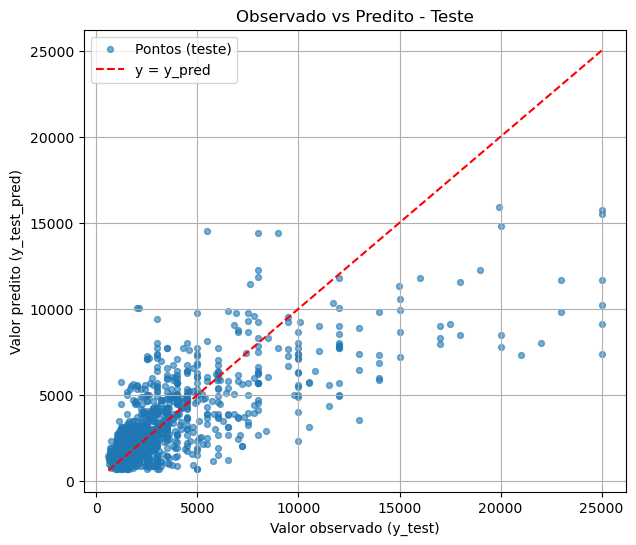

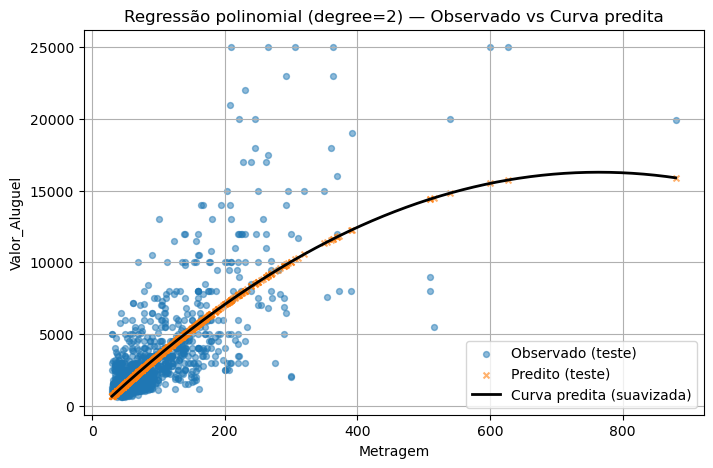

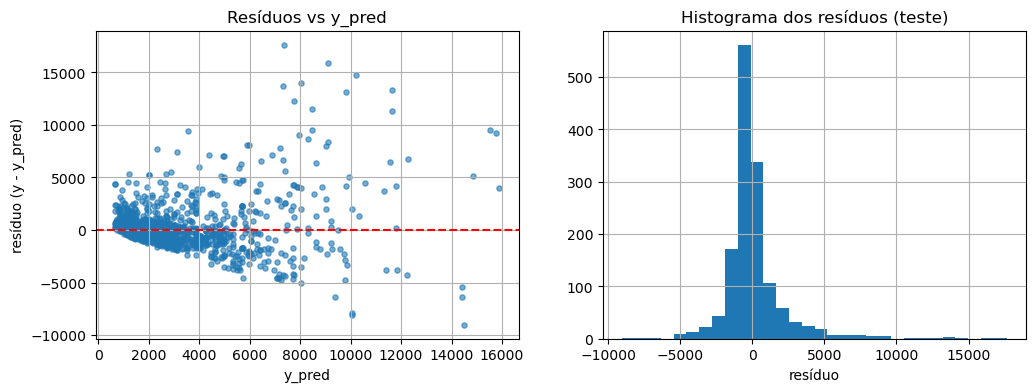

In [7]:
# ---- checagens básicas ----
if 'model' not in globals():
    raise NameError("Variável 'model' não encontrada. Rode a célula de treinamento antes.")
if 'X_test' not in globals() or 'y_test' not in globals():
    raise NameError("X_test e/ou y_test não encontrados. Rode a célula que fez o train_test_split antes.")

# arrays numpy para predição
X_test_arr = X_test if isinstance(X_test, np.ndarray) else (X_test.values if hasattr(X_test, "values") else np.array(X_test))
y_test_arr = y_test if isinstance(y_test, np.ndarray) else np.array(y_test)

# ---- predições ----
y_test_pred = model.predict(X_test_arr)

# ---- métricas ----
r2_test = r2_score(y_test_arr, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_arr, y_test_pred))
mae_test = mean_absolute_error(y_test_arr, y_test_pred)

print("Avaliação - Conjunto de TESTE")
print(f"R²  : {r2_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE : {mae_test:.4f}")

# ---- preparar dados para plots ----
if 'X_used' in globals():
    X_df = X_used if isinstance(X_used, pd.DataFrame) else pd.DataFrame(X_used)
    x_col = X_df.columns[0]
    x_all = X_df.iloc[:, 0].astype(float).values
else:
    # tentar recuperar do X_test 
    if X_test_arr.ndim == 2:
        x_all = X_test_arr[:, 0].astype(float)
        x_col = "x"
    else:
        x_all = X_test_arr.ravel().astype(float)
        x_col = "x"

x_min, x_max = np.min(x_all), np.max(x_all)

# construir grid para curva suave
x_grid = np.linspace(x_min, x_max, 300).reshape(-1, 1)

# transformar grid conforme presença de transformer 'poly' ou formato de X_used
if 'poly' in globals():
    try:
        X_grid = poly.transform(pd.DataFrame(x_grid, columns=[x_col]))
    except Exception:
        X_grid = np.hstack([x_grid, x_grid**2])
else:
    # se X_used tem duas colunas (x e x^2), montar manualmente
    if X_df.shape[1] == 2:
        X_grid = np.hstack([x_grid, (x_grid**2)])
    else:
        # chute conservador: usar somente x
        X_grid = x_grid

y_grid_pred = model.predict(X_grid)

# ---- Plot 1: Observado (teste) vs Predito (teste) ----
plt.figure(figsize=(7,6))
plt.scatter(y_test_arr, y_test_pred, s=18, alpha=0.6, label='Pontos (teste)')
lims = [min(np.min(y_test_arr), np.min(y_test_pred)), max(np.max(y_test_arr), np.max(y_test_pred))]
plt.plot(lims, lims, '--', color='red', label='y = y_pred')
plt.xlabel('Valor observado (y_test)')
plt.ylabel('Valor predito (y_test_pred)')
plt.title('Observado vs Predito - Teste')
plt.legend()
plt.grid(True)
plt.show()

# ---- Plot 2: Curva da regressão (suavizada) + pontos de teste (x vs y) ----
if X_test_arr.ndim == 2:
    x_test_plot = X_test_arr[:, 0].astype(float)
else:
    x_test_plot = X_test_arr.ravel().astype(float)

plt.figure(figsize=(8,5))
plt.scatter(x_test_plot, y_test_arr, s=18, alpha=0.5, label='Observado (teste)')
plt.scatter(x_test_plot, y_test_pred, s=18, alpha=0.6, marker='x', label='Predito (teste)')
plt.plot(x_grid.ravel(), y_grid_pred, color='black', linewidth=2, label='Curva predita (suavizada)')
plt.xlabel(x_col)
plt.ylabel('Valor_Aluguel')
plt.title('Regressão polinomial (degree=2) — Observado vs Curva predita')
plt.legend()
plt.grid(True)
plt.show()

# ---- Plot 3: Resíduos ----
residuals = y_test_arr - y_test_pred
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.scatter(y_test_pred, residuals, s=14, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('y_pred')
plt.ylabel('resíduo (y - y_pred)')
plt.title('Resíduos vs y_pred')
plt.grid(True)

plt.subplot(1,2,2)
plt.hist(residuals, bins=30)
plt.title('Histograma dos resíduos (teste)')
plt.xlabel('resíduo')
plt.grid(True)
plt.show()


AVALIAÇÃO:

* Resumo dos Resultados e Performance:
O modelo atual, que utiliza uma base polinomial de segundo grau, apresentou um R² de 0.57. Isso significa que conseguimos explicar cerca de 57% da variação dos preços de aluguel utilizando apenas a metragem do imóvel. Em termos de erro, o MAE (Erro Médio Absoluto) ficou em aproximadamente R

A diferença considerável entre essas duas métricas confirma que temos outliers (valores atípicos) que estão puxando o erro quadrático para cima.

* Comportamento da Curva e Ajuste
A equação resultante mostra um coeficiente quadrático negativo, o que desenha uma parábola côncava. Na teoria, o valor do aluguel atingiria um pico aos 764 m² e passaria a cair depois disso. Contudo, na prática, como a grande maioria dos nossos dados está abaixo dos 200 m², o modelo se comporta de forma quase linear e crescente no intervalo que realmente importa.

* Gráficos:

Aderência: O gráfico de "Observado vs. Predito" mostra uma boa concentração nos aluguéis de menor valor, mas a dispersão aumenta significativamente à medida que os preços sobem.

Resíduos: O erro do modelo não é constante. Ele é muito mais impreciso para imóveis caros do que para os populares. Além disso, a distribuição dos erros possui "caudas longas", indicando que o modelo ainda sofre para prever os casos extremos.

* Conclusões e Implicações: 
Embora o modelo seja útil para entender a tendência geral do mercado, ele ainda não possui precisão suficiente para servir como ferramenta única de precificação comercial. O erro médio de R$ 1.200 pode ser aceitável para um imóvel de alto padrão, mas é crítico para unidades menores.


# 5 - Rodando um novo modelo, porém testando agora na fase de processamento o degree = 4. + Avaliação.

RESULTADOS (comparação fair - mesmo split):

Degree 2: R2_train=0.5302 | RMSE_train=1957.3508 | MAE_train=1171.7405
          R2_test = 0.5711 | RMSE_test = 2155.4572 | MAE_test = 1225.4696

Degree 4: R2_train=0.5470 | RMSE_train=1922.0311 | MAE_train=1126.7498
          R2_test = 0.5585 | RMSE_test = 2186.8896 | MAE_test = 1194.1280

VEREDICTO: Grau-4 não superou o grau-2 (R² diminuiu e RMSE aumentou no teste).



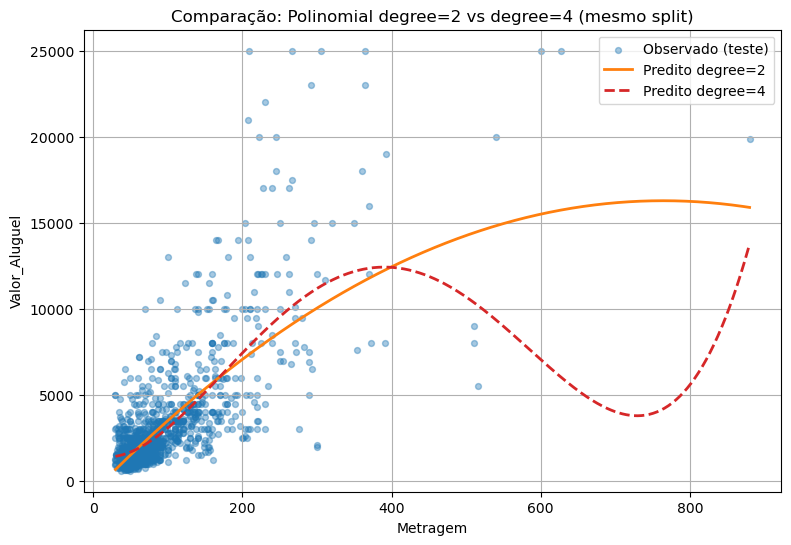

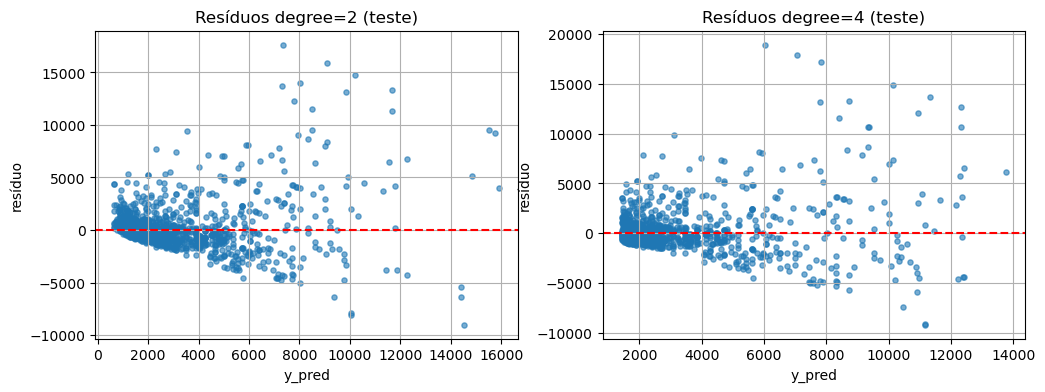

Sumário (tabela):


,r2_test,rmse_test,mae_test
degree,,,
2,0.571054,2155.457159,1225.469554
4,0.558452,2186.889596,1194.128016


In [8]:
# --- assegurar X e y ---
for _name in ('df_imoveis','df','data'):
    if _name in globals():
        df_used = globals()[_name]
        break
else:
    raise NameError("Nenhum DataFrame encontrado nas variáveis padrão ('df_imoveis','df','data').")

required = {'Metragem', 'Valor_Aluguel'}
missing = required - set(df_used.columns)
if missing:
    raise KeyError(f"Colunas ausentes: {missing}. Colunas disponíveis: {list(df_used.columns)}")

X = df_used[['Metragem']].astype(float).copy()
y = df_used['Valor_Aluguel'].astype(float).copy()

# --- split único---
X_arr = X.values
y_arr = y.values
X_train, X_test, y_train, y_test = train_test_split(X_arr, y_arr, test_size=0.2, random_state=42, shuffle=True)

def fit_and_eval(degree, Xtr, Xte, ytr, yte):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    Xtr_poly = poly.fit_transform(Xtr)
    Xte_poly = poly.transform(Xte)
    model = LinearRegression()
    model.fit(Xtr_poly, ytr)
    ytr_pred = model.predict(Xtr_poly)
    yte_pred = model.predict(Xte_poly)
    r2_tr = r2_score(ytr, ytr_pred)
    r2_te = r2_score(yte, yte_pred)
    rmse_tr = np.sqrt(mean_squared_error(ytr, ytr_pred))
    rmse_te = np.sqrt(mean_squared_error(yte, yte_pred))
    mae_tr = mean_absolute_error(ytr, ytr_pred)
    mae_te = mean_absolute_error(yte, yte_pred)
    # try to get feature names if needed
    try:
        feat_names = poly.get_feature_names_out(['Metragem'])
    except Exception:
        try:
            feat_names = poly.get_feature_names(['Metragem'])
        except Exception:
            feat_names = [f"f{i}" for i in range(Xtr_poly.shape[1])]
    return {
        'degree': degree,
        'poly': poly,
        'model': model,
        'Xtr_poly': Xtr_poly,
        'Xte_poly': Xte_poly,
        'ytr_pred': ytr_pred,
        'yte_pred': yte_pred,
        'r2_tr': r2_tr, 'r2_te': r2_te,
        'rmse_tr': rmse_tr, 'rmse_te': rmse_te,
        'mae_tr': mae_tr, 'mae_te': mae_te,
        'feat_names': feat_names
    }

res2 = fit_and_eval(2, X_train, X_test, y_train, y_test)
res4 = fit_and_eval(4, X_train, X_test, y_train, y_test)

# --- imprimir resultados comparativos ---
def print_res(r):
    print(f"Degree {r['degree']}: R2_train={r['r2_tr']:.4f} | RMSE_train={r['rmse_tr']:.4f} | MAE_train={r['mae_tr']:.4f}")
    print(f"          R2_test = {r['r2_te']:.4f} | RMSE_test = {r['rmse_te']:.4f} | MAE_test = {r['mae_te']:.4f}")
    print()

print("RESULTADOS (comparação fair - mesmo split):\n")
print_res(res2)
print_res(res4)

# --- decisão simples: melhor se R2 e RMSE no teste ---
better_r2 = res4['r2_te'] > res2['r2_te']
better_rmse = res4['rmse_te'] < res2['rmse_te']

if better_r2 and better_rmse:
    verdict = "Grau-4 é superior (R² aumentou e RMSE diminuiu no teste)."
elif (better_r2 and not better_rmse) or (not better_r2 and better_rmse):
    verdict = "Resultados mistos (melhora em uma métrica, piora em outra)."
else:
    verdict = "Grau-4 não superou o grau-2 (R² diminuiu e RMSE aumentou no teste)."

print("VEREDICTO:", verdict)
print()

# --- Plot: curva suavizada dos dois modelos + pontos de teste ---
x_min, x_max = X.values.min(), X.values.max()
x_grid = np.linspace(x_min, x_max, 500).reshape(-1,1)

# transformar grids
Xg_2 = res2['poly'].transform(x_grid)
Xg_4 = res4['poly'].transform(x_grid)
y_grid_2 = res2['model'].predict(Xg_2)
y_grid_4 = res4['model'].predict(Xg_4)

plt.figure(figsize=(9,6))
plt.scatter(X_test[:,0], y_test, s=18, alpha=0.4, label='Observado (teste)')
plt.plot(x_grid.ravel(), y_grid_2, color='C1', linewidth=2, label='Predito degree=2')
plt.plot(x_grid.ravel(), y_grid_4, color='C3', linewidth=2, linestyle='--', label='Predito degree=4')
plt.xlabel('Metragem')
plt.ylabel('Valor_Aluguel')
plt.title('Comparação: Polinomial degree=2 vs degree=4 (mesmo split)')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot: resíduos (teste) lado a lado ---
resid2 = y_test - res2['yte_pred']
resid4 = y_test - res4['yte_pred']

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.scatter(res2['yte_pred'], resid2, s=14, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Resíduos degree=2 (teste)')
plt.xlabel('y_pred'); plt.ylabel('resíduo')
plt.grid(True)

plt.subplot(1,2,2)
plt.scatter(res4['yte_pred'], resid4, s=14, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Resíduos degree=4 (teste)')
plt.xlabel('y_pred'); plt.ylabel('resíduo')
plt.grid(True)
plt.show()

# --- entregar os resultados em um dataframe para inspeção ---
summary = pd.DataFrame([
    {'degree':2, 'r2_test': res2['r2_te'], 'rmse_test': res2['rmse_te'], 'mae_test': res2['mae_te']},
    {'degree':4, 'r2_test': res4['r2_te'], 'rmse_test': res4['rmse_te'], 'mae_test': res4['mae_te']}
]).set_index('degree')

print("Sumário (tabela):")
display(summary)

# Retornar objetos úteis ao ambiente
degree2_results = res2
degree4_results = res4


Features (simple): ['Metragem']
Features (multi) : ['Metragem', 'N_Quartos', 'N_Suites', 'N_Vagas', 'N_banheiros']
Linhas após dropna nas colunas usadas: 7203

Executando CV para cada pipeline (isso pode demorar alguns segundos)...

Resumo CV (média ± std):


,scenario,r2_mean,r2_std,rmse_mean,rmse_std,mae_mean,mae_std
0,baseline_multi,0.5963,0.0286,1869.6029,722.7653,1061.2035,47.2460
1,baseline_simple,0.5360,0.0316,2005.9352,793.2750,1184.9891,65.3333
2,lasso4_multi,0.5688,0.0592,1931.7222,824.6857,1082.7242,51.7848
3,lasso4_simple,0.5373,0.0281,2004.1287,800.7593,1174.8374,66.5969
4,ridge4_multi,0.2697,0.3735,2564.2228,1940.4403,1084.2540,64.8148
5,ridge4_simple,0.5454,0.0229,1987.4935,802.0737,1147.6538,64.3588



Melhor cenário segundo R2 médio (CV): baseline_multi (R2=0.5963)
Gerando previsões por cross_val_predict para o melhor cenário para plotar...

Métricas (cross_val_predict) do melhor cenário baseline_multi: R2=0.5979, RMSE=1869.62, MAE=1061.21


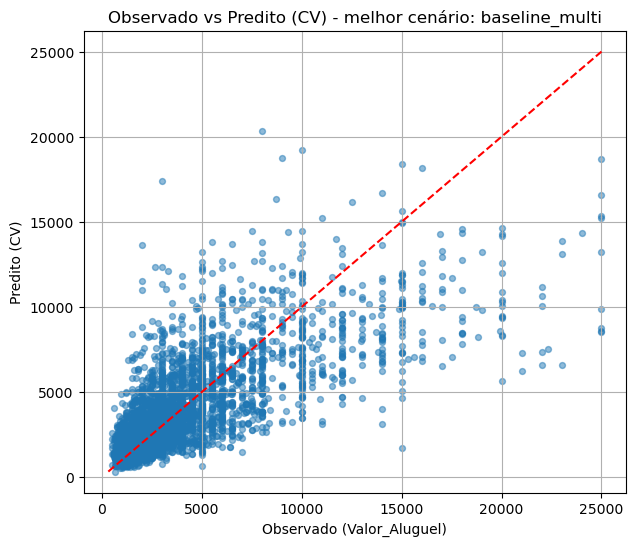


Veredito (univariado - Metragem):
- Ridge degree=4 regularizado melhor que baseline degree=2.

Veredito (multivariado):
- Degree=4 regularizado no conjunto multi NÃO superou claramente o baseline multi degree=2; incluir variáveis já ajuda, mas complexidade extra nem sempre melhora.



In [10]:
# 1) Definir conjuntos de features
simple_features = ['Metragem']   # univariado
multi_features  = ['Metragem', 'N_Quartos', 'N_Suites', 'N_Vagas', 'N_banheiros']  # multivariado (se existir)

# manter apenas as colunas que existem no DataFrame
simple_features = [c for c in simple_features if c in df_used.columns]
multi_features  = [c for c in multi_features if c in df_used.columns]

print("Features (simple):", simple_features)
print("Features (multi) :", multi_features)

# Subset e dropna (para simplicidade)
cols_needed = list(set(simple_features + multi_features + ['Valor_Aluguel']))
df_clean = df_used[cols_needed].dropna().copy()
print("Linhas após dropna nas colunas usadas:", df_clean.shape[0])

X_simple = df_clean[simple_features].astype(float).values
X_multi  = df_clean[multi_features].astype(float).values
y_all    = df_clean['Valor_Aluguel'].astype(float).values

# ---------------------------------------------------------------------
# 2) CV setup e scoring
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'r2': 'r2',
    'neg_mse': 'neg_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error'
}

# ---------------------------------------------------------------------
# 3) Pipelines a comparar
def make_pipeline(degree, estimator):
    # estimator: an sklearn estimator already instantiated
    return Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', estimator)
    ])

# Baseline univariado (degree=2 OLS)
pipe_baseline_simple = make_pipeline(2, LinearRegression())

# Degree=4 regularizado (RidgeCV and LassoCV) - univariado
alphas_ridge = np.logspace(-3, 3, 40)
pipe_ridge4_simple = make_pipeline(4, RidgeCV(alphas=alphas_ridge, cv=5, scoring='r2'))

alphas_lasso = np.logspace(-3, 1, 40)
pipe_lasso4_simple = make_pipeline(4, LassoCV(alphas=alphas_lasso, cv=5, max_iter=10000))

# Baseline multivariado (degree=2 OLS)
pipe_baseline_multi = make_pipeline(2, LinearRegression())

# Degree=4 regularizado (RidgeCV and LassoCV) - multivariado
pipe_ridge4_multi = make_pipeline(4, RidgeCV(alphas=alphas_ridge, cv=5, scoring='r2'))
pipe_lasso4_multi = make_pipeline(4, LassoCV(alphas=alphas_lasso, cv=5, max_iter=10000))

# ---------------------------------------------------------------------
# 4) Rodar cross_validate para cada cenário e coletar métricas médias (CV)
def run_cv(pipe, X, y, cv):
    res = cross_validate(pipe, X, y, scoring=scoring, cv=cv, return_train_score=False, n_jobs=-1)
    # converter neg_mse/neg_mae para rmse/mae
    mean_r2 = np.mean(res['test_r2'])
    std_r2  = np.std(res['test_r2'])
    mean_rmse = np.sqrt(-np.mean(res['test_neg_mse']))
    std_rmse  = np.sqrt(np.abs(np.std(res['test_neg_mse'])))  # nota: interpretação do std de RMSE é aproximada
    mean_mae  = -np.mean(res['test_neg_mae'])
    std_mae   = np.std(-res['test_neg_mae'])
    return {
        'r2_mean': mean_r2, 'r2_std': std_r2,
        'rmse_mean': mean_rmse, 'rmse_std': std_rmse,
        'mae_mean': mean_mae, 'mae_std': std_mae,
        'raw': res
    }

print("\nExecutando CV para cada pipeline (isso pode demorar alguns segundos)...")

results = {}

results['baseline_simple'] = run_cv(pipe_baseline_simple, X_simple, y_all, kf)
results['ridge4_simple']   = run_cv(pipe_ridge4_simple, X_simple, y_all, kf)
results['lasso4_simple']   = run_cv(pipe_lasso4_simple, X_simple, y_all, kf)

results['baseline_multi']  = run_cv(pipe_baseline_multi, X_multi, y_all, kf)
results['ridge4_multi']    = run_cv(pipe_ridge4_multi, X_multi, y_all, kf)
results['lasso4_multi']    = run_cv(pipe_lasso4_multi, X_multi, y_all, kf)

# ---------------------------------------------------------------------
# 5) Mostrar resumo tabular
summary_rows = []
for k, v in results.items():
    summary_rows.append({
        'scenario': k,
        'r2_mean': v['r2_mean'],
        'r2_std': v['r2_std'],
        'rmse_mean': v['rmse_mean'],
        'rmse_std': v['rmse_std'],
        'mae_mean': v['mae_mean'],
        'mae_std': v['mae_std']
    })
summary_df = pd.DataFrame(summary_rows).sort_values('scenario').reset_index(drop=True)
pd.set_option('display.float_format', lambda x: f"{x:0.4f}")
print("\nResumo CV (média ± std):")
display(summary_df)

# ---------------------------------------------------------------------
# 6) Escolher o "melhor" modelo segundo R2 médio e plotar predições com cross_val_predict
# (escolha simples: maior r2_mean)
best_key = max(results.keys(), key=lambda k: results[k]['r2_mean'])
print(f"\nMelhor cenário segundo R2 médio (CV): {best_key} (R2={results[best_key]['r2_mean']:.4f})")

# Criar pipeline correspondente para cross_val_predict (necessário re-instanciar LassoCV por compatibilidade)
pipes_map = {
    'baseline_simple': make_pipeline(2, LinearRegression()),
    'ridge4_simple':   make_pipeline(4, RidgeCV(alphas=alphas_ridge, cv=5, scoring='r2')),
    'lasso4_simple':   make_pipeline(4, LassoCV(alphas=alphas_lasso, cv=5, max_iter=10000)),
    'baseline_multi':  make_pipeline(2, LinearRegression()),
    'ridge4_multi':    make_pipeline(4, RidgeCV(alphas=alphas_ridge, cv=5, scoring='r2')),
    'lasso4_multi':    make_pipeline(4, LassoCV(alphas=alphas_lasso, cv=5, max_iter=10000))
}

# selecionar X usado para o best_key
X_for_best = X_simple if 'simple' in best_key else X_multi
pipe_for_best = pipes_map[best_key]

print("Gerando previsões por cross_val_predict para o melhor cenário para plotar...")
y_pred_cv = cross_val_predict(pipe_for_best, X_for_best, y_all, cv=kf, n_jobs=-1)

# métricas globais (cv-pred)
r2_cv = r2_score(y_all, y_pred_cv)
rmse_cv = np.sqrt(mean_squared_error(y_all, y_pred_cv))
mae_cv = mean_absolute_error(y_all, y_pred_cv)
print(f"\nMétricas (cross_val_predict) do melhor cenário {best_key}: R2={r2_cv:.4f}, RMSE={rmse_cv:.2f}, MAE={mae_cv:.2f}")

# Plot observado vs predito (cross-val)
plt.figure(figsize=(7,6))
plt.scatter(y_all, y_pred_cv, s=18, alpha=0.5)
lims = [min(y_all.min(), y_pred_cv.min()), max(y_all.max(), y_pred_cv.max())]
plt.plot(lims, lims, '--r')
plt.xlabel('Observado (Valor_Aluguel)')
plt.ylabel('Predito (CV)')
plt.title(f'Observado vs Predito (CV) - melhor cenário: {best_key}')
plt.grid(True)
plt.show()

# Se o melhor for simple, também plota curva suavizada (x vs pred) para interpretação
if 'simple' in best_key:
    x_vals = X_simple.ravel()
    x_grid = np.linspace(x_vals.min(), x_vals.max(), 400).reshape(-1,1)
    y_grid_pred = cross_val_predict(pipe_for_best, x_grid, y_all, cv=kf, n_jobs=-1)  # cross_val_predict requer shapes compatíveis
    plt.figure(figsize=(8,5))
    plt.scatter(x_vals, y_all, s=12, alpha=0.3, label='Observado (todos)')
    plt.plot(x_grid.ravel(), y_grid_pred, color='red', linewidth=2, label='Curva CV predita')
    plt.xlabel('Metragem'); plt.ylabel('Valor_Aluguel')
    plt.title('Curva (grau4 regularizado) via cross_val_predict')
    plt.legend(); plt.grid(True); plt.show()

# ---------------------------------------------------------------------
# 7) Veredicto automático sucinto
def simple_verdict(summary_df):
    # comparar baseline_simple vs ridge4_simple / lasso4_simple (univariado)
    base = summary_df[summary_df['scenario']=='baseline_simple'].iloc[0]
    cand_ridge = summary_df[summary_df['scenario']=='ridge4_simple'].iloc[0]
    cand_lasso = summary_df[summary_df['scenario']=='lasso4_simple'].iloc[0]
    msg = "\nVeredito (univariado - Metragem):\n"
    def comp(base, cand):
        better = (cand['r2_mean'] > base['r2_mean']) and (cand['rmse_mean'] < base['rmse_mean'])
        return better
    if comp(base, cand_ridge):
        msg += "- Ridge degree=4 regularizado melhor que baseline degree=2.\n"
    elif comp(base, cand_lasso):
        msg += "- Lasso degree=4 regularizado melhor que baseline degree=2.\n"
    else:
        msg += "- Degree=4 regularizado NÃO superou o baseline degree=2 de forma consistente. Regularização não compensou o aumento de complexidade.\n"
    # multivariado
    msg += "\nVeredito (multivariado):\n"
    base_m = summary_df[summary_df['scenario']=='baseline_multi'].iloc[0]
    cand_m_ridge = summary_df[summary_df['scenario']=='ridge4_multi'].iloc[0]
    cand_m_lasso = summary_df[summary_df['scenario']=='lasso4_multi'].iloc[0]
    if (cand_m_ridge['r2_mean'] > base_m['r2_mean']) and (cand_m_ridge['rmse_mean'] < base_m['rmse_mean']):
        msg += "- Ridge degree=4 (multi) melhor que baseline multi degree=2.\n"
    elif (cand_m_lasso['r2_mean'] > base_m['r2_mean']) and (cand_m_lasso['rmse_mean'] < base_m['rmse_mean']):
        msg += "- Lasso degree=4 (multi) melhor que baseline multi degree=2.\n"
    else:
        msg += "- Degree=4 regularizado no conjunto multi NÃO superou claramente o baseline multi degree=2; incluir variáveis já ajuda, mas complexidade extra nem sempre melhora.\n"
    return msg

print(simple_verdict(summary_df))
# ---------------------------------------------------------------------
# Observação final: se quiser eu salvo `summary_df` e `y_pred_cv`/dados de predições em CSV para inspeção.

* Conclusões da Validação Cruzada

 - O Principal Achado:
   
Após os testes de validação cruzada, o cenário que apresentou o melhor desempenho foi o modelo multivariado de segundo grau. Na prática, os números mostram que adicionar variáveis complementares (quartos, suítes e vagas) trouxe um ganho de precisão muito superior do que simplesmente tentar aumentar a complexidade matemática do modelo (como usar polinômios de grau 4) ou aplicar técnicas de regularização (Ridge/Lasso).

 - Por que esse resultado faz sentido?

Embora a metragem seja um pilar importante, o valor do aluguel é multifatorial. Itens como o número de suítes e vagas de garagem carregam informações práticas que reduzem drasticamente o erro de previsão. Quando tentamos forçar um polinômio de grau 4, o modelo acaba criando oscilações artificiais e instabilidade, algo que nem mesmo a regularização conseguiu compensar.

# 6 - Explique com suas palavras o conceito e a diferença entre Elastic Net, Ridge e Lasso.

Ridge, Lasso e Elastic Net são regressões regularizadas que adicionam uma penalização ao erro para evitar overfitting e controlar a magnitude dos coeficientes.

Ridge usa penalização L2 (soma dos quadrados dos coeficientes): encolhe coeficientes continuamente, mantendo todas as variáveis no modelo (não zera coeficientes) sendo útil quando muitas features estão correlacionadas e você quer estabilidade.

Lasso usa penalização L1 (soma dos valores absolutos): além de encolher, pode zerar coeficientes, fazendo seleção de variáveis automática; funciona bem quando se espera um modelo esparso.

Elastic Net combina L1 e L2 (uma mistura controlada por um parâmetro) oferecendo seleção de variáveis como Lasso e estabilidade frente à multicolinearidade como Ridge, sendo a escolha prática quando há muitas features correlacionadas e você quer tanto regularização quanto seleção.
